In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import wfdb
import ast
import torch
import seaborn as sns
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, confusion_matrix
from tabulate import tabulate
import os
from collections import Counter
from sklearn.preprocessing import StandardScaler

In [2]:
def normalize_data_z_score(data: np.ndarray) -> np.ndarray:
    num_samples, sample_length, num_channels = data.shape
    data_reshaped = data.reshape(-1, num_channels)
    scaler = StandardScaler()
    data_normalized = scaler.fit_transform(data_reshaped)
    return data_normalized.reshape(num_samples, sample_length, num_channels)

In [3]:
path_load = '../../source/data_source_sub'


##train
X_train = np.load(os.path.join(path_load, 'Y_train.npy'))
X_train = normalize_data_z_score(X_train)

y_train = pd.read_csv(os.path.join(path_load, 'Z_train.csv'))
y_train = y_train.drop(columns=['ecg_id'])
y_train = y_train.to_numpy(dtype=np.float32)

z_train = pd.read_csv(os.path.join(path_load, 'T_train.csv'))
z_train = z_train.drop(columns=['ecg_id'])
z_train = z_train.to_numpy(dtype=np.float32)

##test
X_test = np.load(os.path.join(path_load, 'Y_test.npy'))
X_test = normalize_data_z_score(X_test)

y_test = pd.read_csv(os.path.join(path_load, 'Z_test.csv'))
y_test = y_test.drop(columns=['ecg_id'])
y_test = y_test.to_numpy(dtype=np.float32)

z_test = pd.read_csv(os.path.join(path_load, 'T_test.csv'))
z_test = z_test.drop(columns=['ecg_id'])
z_test = z_test.to_numpy(dtype=np.float32)

##validation
X_val = np.load(os.path.join(path_load, 'Y_valid.npy'))
X_val = normalize_data_z_score(X_val)

y_val = pd.read_csv(os.path.join(path_load, 'Z_valid.csv'))
y_val = y_val.drop(columns=['ecg_id'])
y_val = y_val.to_numpy(dtype=np.float32)

z_val = pd.read_csv(os.path.join(path_load, 'T_valid.csv'))
z_val = z_val.drop(columns=['ecg_id'])
z_val = z_val.to_numpy(dtype=np.float32)

table = [
    ["X_train", X_train.shape],
    ["y_train", y_train.shape],
    ["z_train", z_train.shape],
    ["X_test", X_test.shape],
    ["y_test", y_test.shape],
    ["z_test", z_test.shape],
    ["X_val", X_val.shape],
    ["y_val", y_val.shape],
    ["z_val", z_val.shape],
]

print(tabulate(table, headers=["Dataset", "Shape"], tablefmt="grid"))

+-----------+-------------------+
| Dataset   | Shape             |
+===========+===================+
| X_train   | (17441, 1000, 12) |
+-----------+-------------------+
| y_train   | (17441, 5)        |
+-----------+-------------------+
| z_train   | (17441, 23)       |
+-----------+-------------------+
| X_test    | (2203, 1000, 12)  |
+-----------+-------------------+
| y_test    | (2203, 5)         |
+-----------+-------------------+
| z_test    | (2203, 23)        |
+-----------+-------------------+
| X_val     | (2193, 1000, 12)  |
+-----------+-------------------+
| y_val     | (2193, 5)         |
+-----------+-------------------+
| z_val     | (2193, 23)        |
+-----------+-------------------+


In [4]:
columns_of_csv = pd.read_csv(os.path.join(path_load, 'Z_train.csv'))
label_map = {label: i for i, label in enumerate(columns_of_csv.columns[1:])}
print(label_map)

columns_of_csv = pd.read_csv(os.path.join(path_load, 'T_train.csv'))
label_map_sub = {label: i for i, label in enumerate(columns_of_csv.columns[1:])}
print(label_map_sub)

superclass_dict = {
    'NORM': ['NORM'],
    'CD': ['LAFB/LPFB', 'IRBBB', 'ILBBB', 'CLBBB', 'CRBBB', '_AVB', 'IVCB'],
    'HYP': ['LVH', 'RVH', 'LAO/LAE', 'RAO/RAE', 'SEHYP'],
    'MI': ['AMI', 'IMI', 'LMI', 'PMI', 'ISCA', 'ISCI'],
    'STTC': ['ISC_', 'STTC', 'NST_']
}


{'NORM': 0, 'CD': 1, 'HYP': 2, 'MI': 3, 'STTC': 4}
{'NORM': 0, 'LAFB/LPFB': 1, 'IRBBB': 2, 'ILBBB': 3, 'CLBBB': 4, 'CRBBB': 5, '_AVB': 6, 'IVCB': 7, 'WPW': 8, 'LVH': 9, 'RVH': 10, 'LAO/LAE': 11, 'RAO/RAE': 12, 'SEHYP': 13, 'AMI': 14, 'IMI': 15, 'LMI': 16, 'PMI': 17, 'ISCA': 18, 'ISCI': 19, 'ISC_': 20, 'STTC': 21, 'NST_': 22}


In [5]:
import numpy as np


# Define the threshold for the metrics (e.g., F1-Score threshold)

# Identify the subclasses with low F1-Score
low_f1_subclasses = ["ILBBB", "_AVB", "IVCB", "WPW", "RVH", "LAO/LAE", "RAO/RAE", "SEHYP", "LMI", "PMI", "ISCA", "ISCI", "NST_"]

# Function to remove samples based on the low F1-Score subclasses
def remove_low_f1_samples(X, y, z, low_f1_subclasses, label_map_sub):
    # Find the indices to remove based on the low F1-Score subclasses
    to_remove_indices = []
    
    # Iterate over each sample
    for i in range(z.shape[0]):  # Iterate through the samples
        # Check if the sample has a low F1-Score subclass
        sample_labels = [label_map_sub[label] for label in low_f1_subclasses if label in label_map_sub]
        
        if any(z[i, label] == 1 for label in sample_labels):
            to_remove_indices.append(i)
    updated_label_map_sub = {k: v for k, v in label_map_sub.items() if k not in low_f1_subclasses}
    low_index = [label_map_sub[i] for i in low_f1_subclasses]
    # Remove the identified indices from X, y, and z
    X_filtered = np.delete(X, to_remove_indices, axis=0)
    y_filtered = np.delete(y, to_remove_indices, axis=0)
    z_filtered = np.delete(z, to_remove_indices, axis=0)
    z_filtered = np.delete(z_filtered, low_index, axis=1)
    return X_filtered, y_filtered, z_filtered, updated_label_map_sub

# Example usage: Remove samples where the F1-Score of the subclasses in `low_f1_subclasses` is below the threshold

# Assuming you already have X_train, y_train, z_train, X_test, y_test, z_test, etc.
X_train_filtered, y_train_filtered, z_train_filtered, label_map_sub_filtered  = remove_low_f1_samples(X_train, y_train, z_train, low_f1_subclasses, label_map_sub)
X_test_filtered, y_test_filtered, z_test_filtered, _ = remove_low_f1_samples(X_test, y_test, z_test, low_f1_subclasses, label_map_sub)
X_val_filtered, y_val_filtered, z_val_filtered, _ = remove_low_f1_samples(X_val, y_val, z_val, low_f1_subclasses, label_map_sub)

# The filtered datasets are now updated
print("Filtered datasets:")
label_map_sub = label_map_sub_filtered
label_map_sub = {label: idx for idx, label in enumerate(label_map_sub.keys())}

Filtered datasets:


In [6]:
print(z_test_filtered.shape)

(1860, 10)


In [7]:
x_train = torch.from_numpy(X_train_filtered).float()  # float tensor for input
labels_train = torch.from_numpy(y_train_filtered).float()  # float tensor for labels
sub_labels_train = torch.from_numpy(z_train_filtered).float()

x_val = torch.from_numpy(X_val_filtered).float()
labels_val = torch.from_numpy(y_val_filtered).float()
sub_labels_val = torch.from_numpy(z_val_filtered).float()

x_test = torch.from_numpy(X_test_filtered).float()
lables_test = torch.from_numpy(y_test_filtered).float()
sub_labels_test = torch.from_numpy(z_test_filtered).float()

batch_size = 32

train_dataset = TensorDataset(x_train, labels_train, sub_labels_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(x_val, labels_val, sub_labels_val)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

test = TensorDataset(x_test, lables_test, sub_labels_test)
test_loader = DataLoader(test, batch_size=batch_size, shuffle=False)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Basic Residual Block for ResNet (with Skip Connections)
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super(ResidualBlock, self).__init__()
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding)
        self.bn = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        
        # Skip connection (identity or convolution)
        self.skip = nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride, padding=0) if in_channels != out_channels else nn.Identity()

    def forward(self, x):
        out = self.conv(x)
        out = self.bn(out)
        out = self.relu(out)
        out = out + self.skip(x)  # Skip connection
        return out

# SE-ResNet Block (Squeeze and Excitation)
class SEResNetBlock(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super(SEResNetBlock, self).__init__()
        self.residual = ResidualBlock(in_channels, in_channels)
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Linear(in_channels, in_channels // reduction)
        self.fc2 = nn.Linear(in_channels // reduction, in_channels)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        res = self.residual(x)
        se = self.avg_pool(res)
        se = se.view(se.size(0), -1)
        se = self.fc1(se)
        se = self.fc2(se)
        se = self.sigmoid(se).view(se.size(0), -1, 1)
        return res * se  # Element-wise multiplication

# Multi-Head Attention Mechanism
class MultiHeadAttention(nn.Module):
    def __init__(self, embed_size, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.embed_size = embed_size
        self.head_dim = embed_size // num_heads

        assert self.head_dim * num_heads == embed_size, "Embedding size must be divisible by number of heads"

        self.values = nn.Linear(embed_size, embed_size)
        self.keys = nn.Linear(embed_size, embed_size)
        self.queries = nn.Linear(embed_size, embed_size)
        self.fc_out = nn.Linear(embed_size, embed_size)

    def forward(self, values, keys, query):
        batch_size = query.shape[0]
        value_len, key_len, query_len = values.shape[1], keys.shape[1], query.shape[1]

        # Project to embed_size first
        values = self.values(values)  # [B, T, embed_size]
        keys = self.keys(keys)        # [B, T, embed_size]
        query = self.queries(query)   # [B, T, embed_size]

        # Now reshape for multi-head
        values = values.reshape(batch_size, value_len, self.num_heads, self.head_dim)
        keys = keys.reshape(batch_size, key_len, self.num_heads, self.head_dim)
        query = query.reshape(batch_size, query_len, self.num_heads, self.head_dim)

        values = values.permute(2, 0, 1, 3)
        keys = keys.permute(2, 0, 1, 3)
        query = query.permute(2, 0, 1, 3)

        energy = torch.matmul(query, keys.permute(0, 1, 3, 2))
        attention = torch.softmax(energy / (self.head_dim ** 0.5), dim=-1)

        out = torch.matmul(attention, values)
        out = out.permute(1, 2, 0, 3).contiguous().view(batch_size, query_len, -1)

        out = self.fc_out(out)
        return out

# ECG Model with ResNet, SE-ResNet, Multiple Attention, and Late Fusion
class ECGMultiTaskNet(nn.Module):
    def __init__(self, in_channels=12, base_channels=64, hidden_size=128, num_classes_5=5, num_classes_23=10, num_heads=8):
        super(ECGMultiTaskNet, self).__init__()

        # CNN layers for feature extraction
        self.conv1 = nn.Conv1d(in_channels, base_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(base_channels, base_channels * 2, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(kernel_size=2)

        # Residual and SE-ResNet Block
        self.resnet = ResidualBlock(base_channels * 2, base_channels * 2)
        self.seresnet = SEResNetBlock(base_channels * 2)

        # Multi-Head Attention layer
        self.attention = MultiHeadAttention(embed_size=base_channels * 2, num_heads=num_heads)

        # BiGRU layer for sequential learning
        self.bigru = nn.GRU(base_channels * 2, hidden_size, bidirectional=True, batch_first=True)

        # Output layers for multi-label classification (5 classes and 23 classes)
        self.fc_5 = nn.Linear(hidden_size * 2, num_classes_5)  # 5 output labels
        self.fc_23 = nn.Linear(hidden_size * 2, num_classes_23)  # 23 output labels

    def forward(self, x):
        # Transpose input from [B, T, C] to [B, C, T]
        x = x.permute(0, 2, 1)  # Now x is of shape [B, C, T]

        # CNN feature extraction
        x = F.relu(self.conv1(x))
        x = self.pool(F.relu(self.conv2(x)))

        # Residual and SE-ResNet block
        x = self.resnet(x)
        x = self.seresnet(x)

        # Multi-Head Attention mechanism
        x = x.permute(0, 2, 1)
        x_attention = self.attention(x, x, x)

        # BiGRU processing
        
        out, _ = self.bigru(x_attention)

        # Get the last time step output for classification
        out = out[:, -1, :]  # [B, 2H] (concatenated forward and backward outputs)

        # Late Fusion of outputs from 5 classes and 23 classes
        output_5 = self.fc_5(out)  # [B, 5] (5 binary class outputs)
        output_23 = self.fc_23(out)  # [B, 23] (23 binary class outputs)

        return output_5, output_23

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ECGMultiTaskNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

In [10]:
def multi_task_loss(output_main, target_main, output_aux, target_aux, model):
    criterion = nn.BCEWithLogitsLoss()
    loss_main = criterion(output_main, target_main)
    loss_aux = criterion(output_aux, target_aux)

    #weighted_loss = (main_weight * weights[0] * loss_main) + (aux_weight * weights[1] * loss_aux)
    #weighted_loss = (lambda_weight * loss_main) + ((1-lambda_weight) * loss_aux)
    weighted_loss = (loss_main) + (0.5 * loss_aux)

    return weighted_loss, loss_main.item(), loss_aux.item()

In [11]:
# 4. Training loop
num_epochs = 30
best_val_loss = float('inf')
best_model_wts = None  # To save the best model
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    train_main_loss = 0.0
    train_aux_loss = 0.0
    for inputs, targets, sub_targets in train_loader:
        inputs, targets, sub_targets = inputs.to(device), targets.to(device), sub_targets.to(device)

        optimizer.zero_grad()
        outputs_main, outputs_aux = model(inputs)  # CNN expects (batch, channels, seq_len)
        loss, train_lm, train_la = multi_task_loss(outputs_main, targets, outputs_aux, sub_targets, model)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        train_main_loss += train_lm * inputs.size(0)
        train_aux_loss += train_la * inputs.size(0)

    train_loss /= len(train_loader.dataset)
    train_main_loss /= len(train_loader.dataset)
    train_aux_loss /= len(train_loader.dataset)

    # Validation
    model.eval()
    val_loss = 0.0
    val_main_loss = 0.0
    val_aux_loss = 0.0
    with torch.no_grad():
        for inputs, targets, sub_targets in val_loader:
            inputs, targets, sub_targets = inputs.to(device), targets.to(device), sub_targets.to(device)
            
            outputs_main, outputs_aux = model(inputs)  # CNN expects (batch, channels, seq_len)
            loss_, val_lm, val_la = multi_task_loss(outputs_main, targets, outputs_aux, sub_targets, model)
            val_loss += loss_.item() * inputs.size(0)
            val_main_loss += val_lm * inputs.size(0)
            val_aux_loss += val_la * inputs.size(0)

    val_loss /= len(val_loader.dataset)
    val_main_loss /= len(val_loader.dataset)
    val_aux_loss /= len(val_loader.dataset)
    
    # Print with color and progress bar
    epoch_str = f"\033[1;36mEpoch {epoch+1}/{num_epochs}\033[0m"
    bar_len = 30
    filled_len = int(round(bar_len * (epoch+1) / float(num_epochs)))
    bar = '=' * filled_len + '-' * (bar_len - filled_len)
    print(f"{epoch_str} [{bar}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"Loss Train Main: {train_main_loss:.4f}, Loss Train Aux: {train_aux_loss:.4f} | Loss Val Main: {val_main_loss:.4f}, Loss Val Aux: {val_aux_loss:.4f}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        print(f"Found best save with Val Loss: {val_loss:.4f}")
        best_model_wts = model.state_dict()  # Save the best model
        epochs_without_improvement = 0  # Reset the counter
        
if best_model_wts is not None:
    model.load_state_dict(best_model_wts)
model.eval()
test_loss = 0.0
criterion = nn.BCEWithLogitsLoss()  # or your chosen loss

with torch.no_grad():
    for inputs, targets, sub_targets in test_loader:
        inputs, targets, sub_targets = inputs.to(device), targets.to(device), sub_targets.to(device)
        
        outputs_main, outputs_aux = model(inputs)  # CNN expects (batch, channels, seq_len)
        loss, train_lm, train_la = multi_task_loss(outputs_main, targets, outputs_aux, sub_targets, model)
        test_loss += loss.item() * inputs.size(0)

test_loss /= len(test_loader.dataset)
print(f"Test Loss: {test_loss:.4f}")

Epoch 1/30 [=-----------------------------] | Train Loss: 0.4311 | Val Loss: 0.4433
Loss Train Main: 0.3236, Loss Train Aux: 0.2149 | Loss Val Main: 0.3319, Loss Val Aux: 0.2228
Found best save with Val Loss: 0.4433
Epoch 2/30 [==----------------------------] | Train Loss: 0.3501 | Val Loss: 0.3484
Loss Train Main: 0.2638, Loss Train Aux: 0.1726 | Loss Val Main: 0.2629, Loss Val Aux: 0.1711
Found best save with Val Loss: 0.3484
Epoch 3/30 [===---------------------------] | Train Loss: 0.3236 | Val Loss: 0.4027
Loss Train Main: 0.2453, Loss Train Aux: 0.1565 | Loss Val Main: 0.3087, Loss Val Aux: 0.1879
Epoch 4/30 [====--------------------------] | Train Loss: 0.3092 | Val Loss: 0.3250
Loss Train Main: 0.2364, Loss Train Aux: 0.1455 | Loss Val Main: 0.2485, Loss Val Aux: 0.1530
Found best save with Val Loss: 0.3250
Epoch 5/30 [=====-------------------------] | Train Loss: 0.2948 | Val Loss: 0.3679
Loss Train Main: 0.2263, Loss Train Aux: 0.1371 | Loss Val Main: 0.2807, Loss Val Aux: 0.1

In [12]:
def performance_evaluation(model=model, dataset=test_loader, dataset_name="Test Set"):
    all_targets = []
    all_preds = []
    all_sub_targets = []
    all_sub_preds = []

    model.eval()
    with torch.no_grad():
        for inputs, targets, sub_targets in dataset:
            inputs, targets, sub_targets = inputs.to(device), targets.to(device), sub_targets.to(device)
            outputs_main, output_aux = model(inputs)
            probs = torch.sigmoid(outputs_main)
            preds = (probs > 0.5).int()

            probs_sub = torch.sigmoid(output_aux)
            preds_sub = (probs_sub > 0.5).int()

            all_targets.append(targets.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_sub_targets.append(sub_targets.cpu().numpy())
            all_sub_preds.append(preds_sub.cpu().numpy())

    # Stack arrays
    all_targets = np.vstack(all_targets)
    all_preds = np.vstack(all_preds)
    all_sub_targets = np.vstack(all_sub_targets)
    all_sub_preds = np.vstack(all_sub_preds)

    num_classes = all_targets.shape[1]
    num_sub_classes = all_sub_targets.shape[1]

    # Check for shape consistency with label_map_sub
    if len(label_map_sub) != num_sub_classes:
        print(f"Warning: Length of 'label_map_sub' ({len(label_map_sub)}) does not match the number of sub-classes ({num_sub_classes})")
        print("Please ensure that 'label_map_sub' is correctly defined.")
        return

    # Prepare table data
    table_data = []
    table_sub_data = []
    headers = ["Class", "Precision", "Recall (Sensitivity)", "Specificity", "F1-Score", "TN", "FP", "FN", "TP", "Total"]

    # Main target evaluation (classes)
    for i in range(len(label_map)):
        key, value = list(label_map.items())[i]
        y_true = all_targets[:, i]
        y_pred = all_preds[:, i]

        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        cm = confusion_matrix(y_true, y_pred)

        if cm.size == 4:
            TN, FP, FN, TP = cm.ravel()
            total = TN + FP + FN + TP
            specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
            f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
            # Format with percentage
            TN_str = f"{TN} ({TN/total*100:.1f}%)"
            FP_str = f"{FP} ({FP/total*100:.1f}%)"
            FN_str = f"{FN} ({FN/total*100:.1f}%)"
            TP_str = f"{TP} ({TP/total*100:.1f}%)"
        else:
            TN_str = FP_str = FN_str = TP_str = "0 (0.0%)"
            specificity = 0.0

        table_data.append([
            key,
            f"{precision:.4f}",
            f"{recall:.4f}",
            f"{specificity:.4f}",
            f"{f1_score:.4f}",
            TN_str,
            FP_str,
            FN_str,
            TP_str,
        ])

    # Sub-target evaluation (sub-classes)
    for i in range(len(label_map_sub)):
        key, value = list(label_map_sub.items())[i]
        y_true = all_sub_targets[:, i]
        y_pred = all_sub_preds[:, i]

        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        cm = confusion_matrix(y_true, y_pred)

        if cm.size == 4:
            TN, FP, FN, TP = cm.ravel()
            total = TN + FP + FN + TP
            specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
            f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
            # Format with percentage
            TN_str = f"{TN} ({TN/total*100:.1f}%)"
            FP_str = f"{FP} ({FP/total*100:.1f}%)"
            FN_str = f"{FN} ({FN/total*100:.1f}%)"
            TP_str = f"{TP} ({TP/total*100:.1f}%)"
        else:
            TN_str = FP_str = FN_str = TP_str = "0 (0.0%)"
            specificity = 0.0

        table_sub_data.append([
            key,
            f"{precision:.4f}",
            f"{recall:.4f}",
            f"{specificity:.4f}",
            f"{f1_score:.4f}",
            TN_str,
            FP_str,
            FN_str,
            TP_str,
        ])

    print(f"\n------------Performance Evaluation Metrics per Class({dataset_name}) -----------\n")
    print(tabulate(table_data, headers=headers, tablefmt="grid"))
    print(tabulate(table_sub_data, headers=headers, tablefmt="grid"))

    return all_targets, all_preds


In [13]:
targets_train, preds_train = performance_evaluation(model, train_loader, "Train Set")
targets_val, preds_val = performance_evaluation(model, val_loader, "Val Set")
targets_test, preds_test = performance_evaluation(model, test_loader, "Test Set")


------------Performance Evaluation Metrics per Class(Train Set) -----------

+---------+-------------+------------------------+---------------+------------+---------------+------------+------------+--------------+
| Class   |   Precision |   Recall (Sensitivity) |   Specificity |   F1-Score | TN            | FP         | FN         | TP           |
+=========+=============+========================+===============+============+===============+============+============+==============+
| NORM    |      0.9653 |                 0.9748 |        0.9628 |     0.97   | 6861 (46.7%)  | 265 (1.8%) | 190 (1.3%) | 7361 (50.2%) |
+---------+-------------+------------------------+---------------+------------+---------------+------------+------------+--------------+
| CD      |      0.9493 |                 0.869  |        0.9901 |     0.9074 | 11969 (81.5%) | 120 (0.8%) | 339 (2.3%) | 2249 (15.3%) |
+---------+-------------+------------------------+---------------+------------+---------------+-----

In [14]:
def plot_confusion_matrix_per_class_multi(y_true_list, y_pred_list, class_names=None, set_names=None):
    """
    Plot confusion matrices for multiple sets (e.g., test, val, train) in columns.
    y_true_list, y_pred_list: list of arrays, each for a set.
    set_names: list of names for each set.
    """
    metric_label = ["TN", "FP", "FN", "TP"]
    num_sets = len(y_true_list)
    num_classes = y_true_list[0].shape[1]
    if set_names is None:
        set_names = [f"Set {i+1}" for i in range(num_sets)]
    if class_names is None:
        class_names = [str(i) for i in range(num_classes)]

    for class_idx in range(num_classes):
        fig, axes = plt.subplots(1, num_sets, figsize=(5*num_sets, 4))
        if num_sets == 1:
            axes = [axes]
        for set_idx in range(num_sets):
            y_true = y_true_list[set_idx][:, class_idx]
            y_pred = y_pred_list[set_idx][:, class_idx]
            cm = confusion_matrix(y_true, y_pred)
            total = np.sum(cm)
            if cm.size == 4:
                annot = np.empty_like(cm).astype(str)
                for r in range(2):
                    for c in range(2):
                        count = cm[r, c]
                        row_sum = np.sum(cm[r, :])
                        row_percent = 100 * count / row_sum if row_sum > 0 else 0
                        annot[r, c] = f"{count}\n({metric_label[r*2+c]}:{row_percent:.1f}%)"
            else:
                annot = cm
            sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', cbar=False,
                        xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'],
                        ax=axes[set_idx])
            axes[set_idx].set_title(f"{set_names[set_idx]}")
            axes[set_idx].set_xlabel('Predicted label')
            axes[set_idx].set_ylabel('True label')
        plt.suptitle(f'Confusion Matrix - {class_names[class_idx]}', fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

confusion_matrix (Test Set)


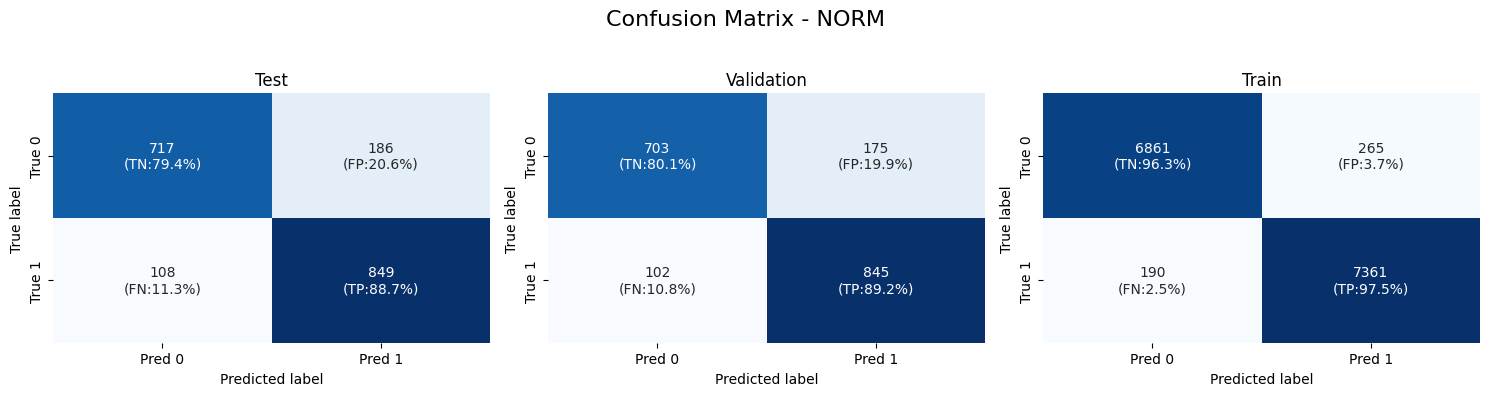

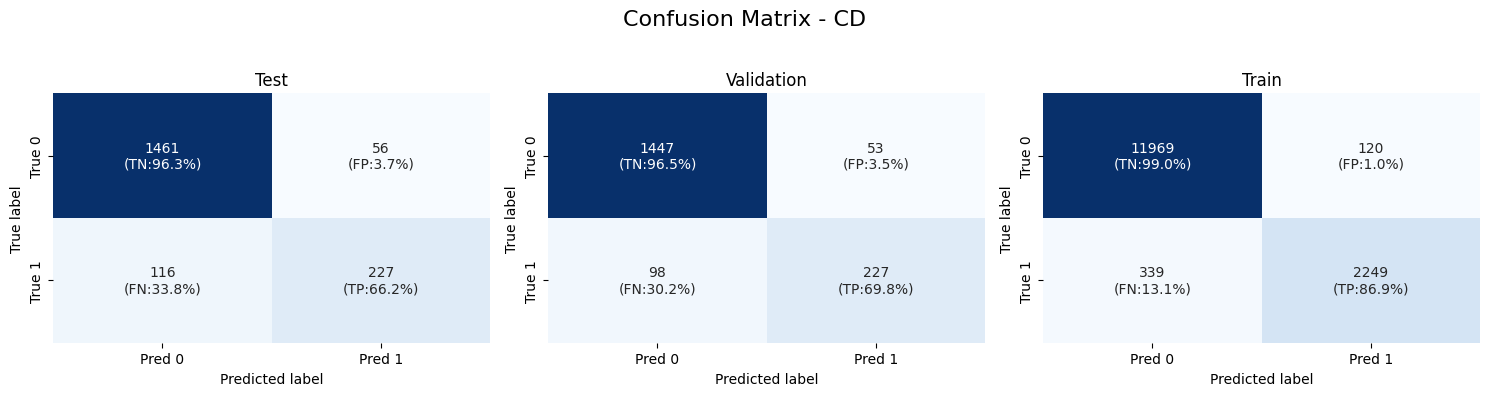

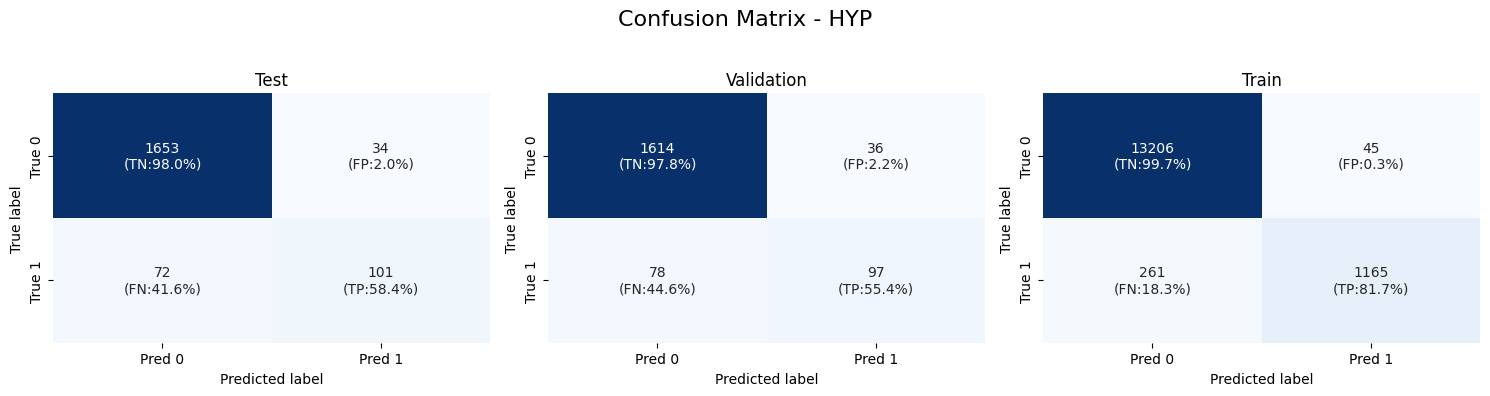

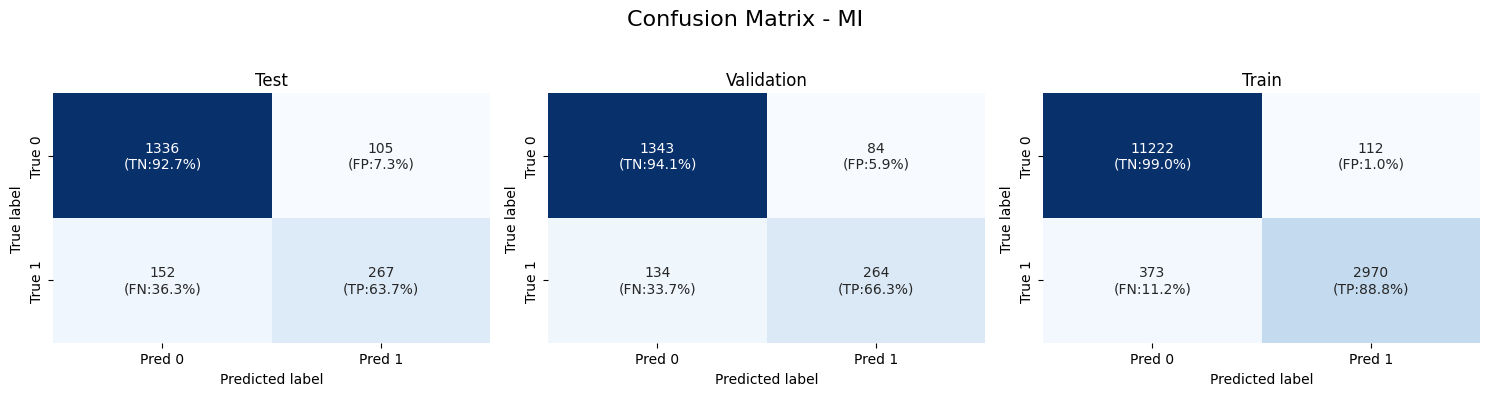

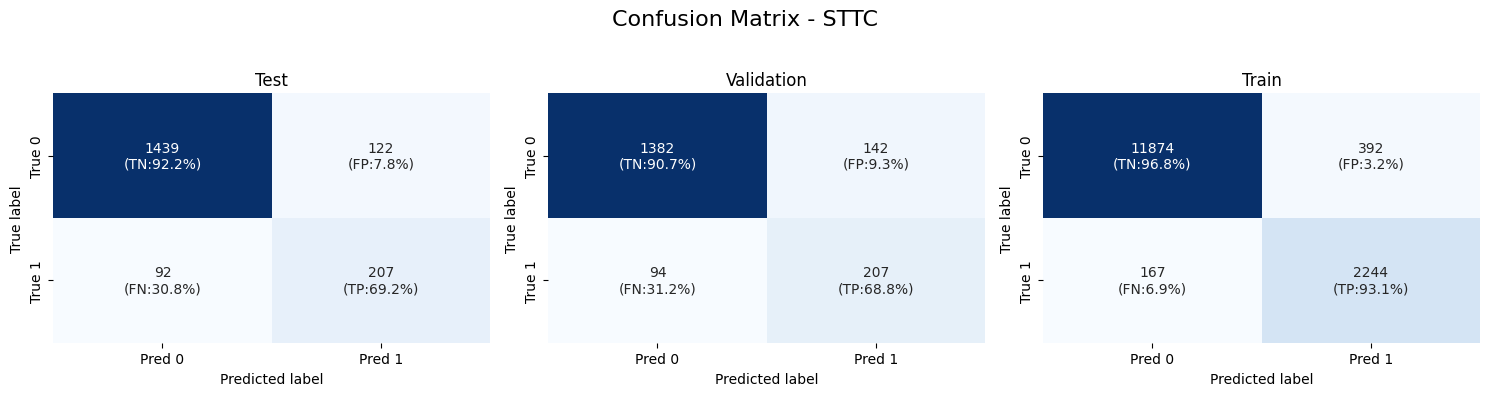

In [15]:
print("confusion_matrix (Test Set)")
#plot_confusion_matrix_per_class(targets_test, preds_test, list(classes_name.keys()))
set_names = ["Test", "Validation", "Train"]
plot_confusion_matrix_per_class_multi(
    [targets_test, targets_val, targets_train],
    [preds_test, preds_val, preds_train],
    class_names=list(label_map.keys()),
    set_names=set_names
)